# movie review sentiment classification

In [1]:
import os, re, random, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import logging as hf_logging

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('device:', device)

device: mps


## data prep

load, drop duplicate rows, strip the `<br />` html tags that show up in most reviews, map sentiment to 0 negative and 1 positive.

In [3]:
df = pd.read_csv('imdb_dataset.csv')
print('raw', df.shape)
df = df.drop_duplicates().reset_index(drop=True)
print('after dropping dups', df.shape)

def clean(t):
    t = re.sub(r'<[^>]+>', ' ', t)        # strip html tags
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['review'] = df['review'].apply(clean)
df['label'] = (df['sentiment'] == 'positive').astype(int)
print(df['label'].value_counts())
df.head(2)

raw (50000, 2)
after dropping dups (49582, 2)


label
1    24884
0    24698
Name: count, dtype: int64


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. The filming tec...,positive,1


## review length

word count  median 172  95th 585  max 2459


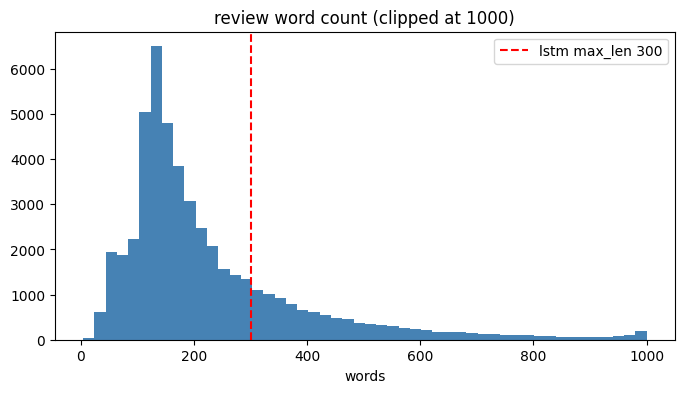

In [4]:
wc = df['review'].str.split().str.len()
print('word count  median', int(wc.median()), ' 95th', int(wc.quantile(.95)), ' max', int(wc.max()))

plt.figure(figsize=(8,4))
plt.hist(wc.clip(upper=1000), bins=50, color='steelblue')
plt.axvline(300, color='red', ls='--', label='lstm max_len 300')
plt.title('review word count (clipped at 1000)'); plt.xlabel('words'); plt.legend(); plt.show()

In [5]:
tr_df, te_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=SEED)
ytr, yte = tr_df['label'].values, te_df['label'].values
print('train', len(tr_df), ' test', len(te_df))

train 39665  test 9917


In [ ]:
# shared eval helper, used for all three models
def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f'{name}: test accuracy {acc:.4f}')
    print(classification_report(y_true, y_pred, target_names=['negative','positive']))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=['neg','pos']).plot(cmap='Blues')
    plt.title(name); plt.show()
    return acc

## model 1: tf idf plus logistic regression

tfidf + logreg: test accuracy 0.9047
              precision    recall  f1-score   support

    negative       0.92      0.89      0.90      4940
    positive       0.89      0.92      0.91      4977

    accuracy                           0.90      9917
   macro avg       0.91      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



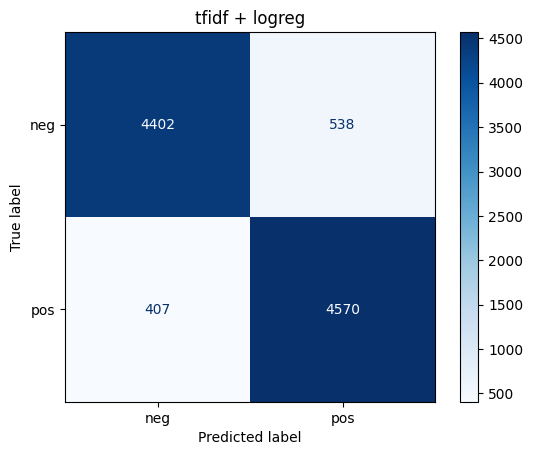

In [7]:
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=20000, min_df=2)
Xtr = tfidf.fit_transform(tr_df['review'])
Xte = tfidf.transform(te_df['review'])

logreg = LogisticRegression()
logreg.fit(Xtr, ytr)
lr_pred = logreg.predict(Xte)
lr_acc = report('tfidf + logreg', yte, lr_pred)

## model 2: lstm from scratch

build a vocab from the training reviews, turn each review into a padded id sequence, then an embedding plus bidirectional lstm plus a linear head.

In [9]:
VOCAB_SIZE = 20000
MAX_LEN = 300   # ~300 words. the distilbert max_length 256 below covers similar actual content since bert splits words into subword tokens

cnt = Counter()
for r in tr_df['review']:
    cnt.update(r.lower().split())
# index 0 is pad, 1 is unk
itos = ['<pad>', '<unk>'] + [w for w, _ in cnt.most_common(VOCAB_SIZE - 2)]
stoi = {w: i for i, w in enumerate(itos)}

def encode(t):
    ids = [stoi.get(w, 1) for w in t.lower().split()[:MAX_LEN]]
    ids += [0] * (MAX_LEN - len(ids))
    return ids

Xtr_seq = np.array([encode(r) for r in tr_df['review']], dtype=np.int64)
Xte_seq = np.array([encode(r) for r in te_df['review']], dtype=np.int64)
print('vocab', len(itos), ' train seq', Xtr_seq.shape)

vocab 20000  train seq (39665, 300)


In [10]:
class SeqDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

class LSTMClf(nn.Module):
    def __init__(self, vocab, emb=128, hid=128):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hid, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(hid * 2, 1)
    def forward(self, x):
        e = self.emb(x)
        _, (h, _) = self.lstm(e)
        h = torch.cat([h[-2], h[-1]], dim=1)   # last state of both directions
        return self.fc(self.drop(h)).squeeze(1)

In [ ]:
EMB_DIM = 128
HID_DIM = 128
LR = 1e-3
BATCH = 64
EPOCHS = 6

tr_i, va_i = train_test_split(np.arange(len(tr_df)), test_size=0.1, stratify=ytr, random_state=SEED)
tr_dl = DataLoader(SeqDS(Xtr_seq[tr_i], ytr[tr_i]), batch_size=BATCH, shuffle=True)
va_dl = DataLoader(SeqDS(Xtr_seq[va_i], ytr[va_i]), batch_size=BATCH)

lstm = LSTMClf(VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)
opt = torch.optim.Adam(lstm.parameters(), lr=LR)
crit = nn.BCEWithLogitsLoss()

hist = {'tr_loss': [], 'va_loss': [], 'va_acc': []}
best = 0.0
for ep in range(1, EPOCHS + 1):
    lstm.train(); tl = 0.0
    for xb, yb in tr_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(lstm(xb), yb)
        loss.backward(); opt.step()
        tl += loss.item() * len(yb)
    tl /= len(tr_i)

    lstm.eval(); vl = 0.0; correct = 0
    with torch.no_grad():
        for xb, yb in va_dl:
            xb, yb = xb.to(device), yb.to(device)
            out = lstm(xb)
            vl += crit(out, yb).item() * len(yb)
            correct += ((out > 0).float() == yb).sum().item()
    vl /= len(va_i); vacc = correct / len(va_i)
    hist['tr_loss'].append(tl); hist['va_loss'].append(vl); hist['va_acc'].append(vacc)
    if vacc > best:
        best = vacc
        torch.save(lstm.state_dict(), 'best_lstm.pt')
    print(f'ep {ep}  tr_loss {tl:.3f}  va_loss {vl:.3f}  va_acc {vacc:.3f}')
print('best val acc', round(best, 4))

ep 1  tr_loss 0.632  va_loss 0.546  va_acc 0.734


ep 2  tr_loss 0.511  va_loss 0.538  va_acc 0.728


ep 3  tr_loss 0.414  va_loss 0.455  va_acc 0.796


ep 4  tr_loss 0.306  va_loss 0.387  va_acc 0.845


ep 5  tr_loss 0.270  va_loss 0.389  va_acc 0.840


ep 6  tr_loss 0.277  va_loss 0.395  va_acc 0.842
best val acc 0.8452


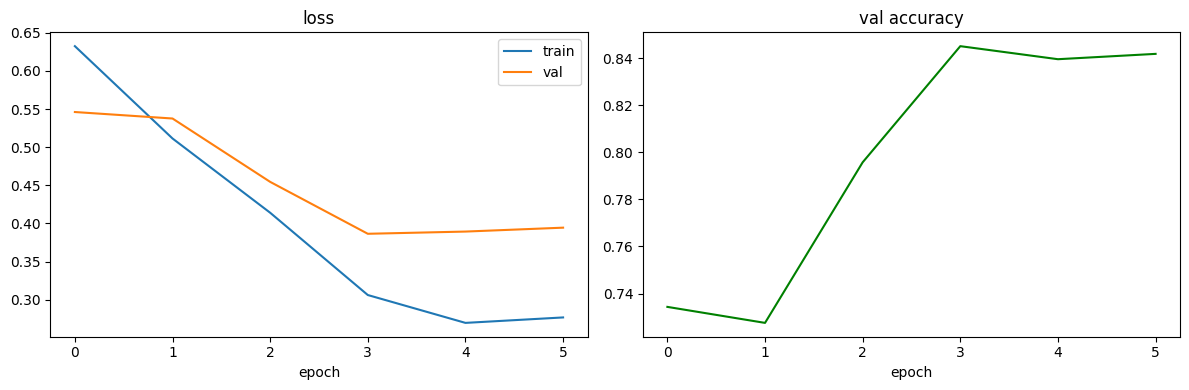

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist['tr_loss'], label='train'); ax[0].plot(hist['va_loss'], label='val')
ax[0].set_title('loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(hist['va_acc'], color='green')
ax[1].set_title('val accuracy'); ax[1].set_xlabel('epoch')
plt.tight_layout(); plt.show()

lstm: test accuracy 0.8617
              precision    recall  f1-score   support

    negative       0.89      0.83      0.86      4940
    positive       0.84      0.90      0.87      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



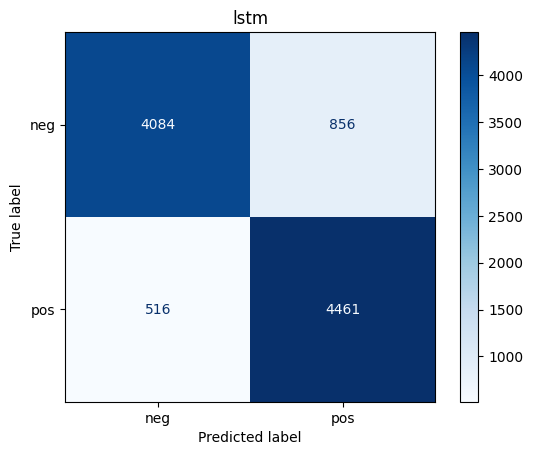

In [13]:
lstm.load_state_dict(torch.load('best_lstm.pt', map_location=device))
lstm.eval()
te_dl = DataLoader(SeqDS(Xte_seq, yte), batch_size=128)
lstm_pred = []
with torch.no_grad():
    for xb, _ in te_dl:
        lstm_pred.append((lstm(xb.to(device)) > 0).long().cpu().numpy())
lstm_pred = np.concatenate(lstm_pred)
lstm_acc = report('lstm', yte, lstm_pred)

## model 3: fine tune distilbert

distilbert pretrained on a lot of text, then fine tuned on the reviews. one epoch on the full 50k.

In [ ]:
CKPT = 'distilbert-base-uncased'
BERT_MAXLEN = 256   
BERT_BATCH = 16
BERT_LR = 2e-5
BERT_EPOCHS = 1     

tok = AutoTokenizer.from_pretrained(CKPT)

def tok_all(texts):
    return tok(list(texts), truncation=True, padding='max_length',
               max_length=BERT_MAXLEN, return_tensors='pt')

tr_enc = tok_all(tr_df['review'])
te_enc = tok_all(te_df['review'])

class BertDS(Dataset):
    def __init__(self, enc, y):
        self.enc = enc
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.enc.items()}, self.y[i]

def subset(enc, idx):
    return {k: v[idx] for k, v in enc.items()}

# reuse the same train/val index split as the lstm
btr_dl = DataLoader(BertDS(subset(tr_enc, tr_i), ytr[tr_i]), batch_size=BERT_BATCH, shuffle=True)
bva_dl = DataLoader(BertDS(subset(tr_enc, va_i), ytr[va_i]), batch_size=BERT_BATCH)
bte_dl = DataLoader(BertDS(te_enc, yte), batch_size=BERT_BATCH)
print('tokenized. train batches', len(btr_dl))

tokenized. train batches 2232


In [15]:
bert = AutoModelForSequenceClassification.from_pretrained(CKPT, num_labels=2).to(device)
opt = torch.optim.AdamW(bert.parameters(), lr=BERT_LR)

best_b = 0.0
for ep in range(1, BERT_EPOCHS + 1):
    bert.train()
    for i, (enc, yb) in enumerate(btr_dl):
        enc = {k: v.to(device) for k, v in enc.items()}
        yb = yb.to(device)
        opt.zero_grad()
        out = bert(**enc, labels=yb)
        out.loss.backward(); opt.step()
        if i % 400 == 0:
            print(f'  ep {ep} step {i}/{len(btr_dl)}  loss {out.loss.item():.3f}')

    bert.eval(); correct = 0; n = 0
    with torch.no_grad():
        for enc, yb in bva_dl:
            enc = {k: v.to(device) for k, v in enc.items()}
            pred = bert(**enc).logits.argmax(1).cpu()
            correct += (pred == yb).sum().item(); n += len(yb)
    vacc = correct / n
    print(f'ep {ep}  val acc {vacc:.4f}')
    if vacc > best_b:
        best_b = vacc
        torch.save(bert.state_dict(), 'best_distilbert.pt')
print('best val acc', round(best_b, 4))

  ep 1 step 0/2232  loss 0.677


  ep 1 step 400/2232  loss 0.606


  ep 1 step 800/2232  loss 0.589


  ep 1 step 1200/2232  loss 0.324


  ep 1 step 1600/2232  loss 0.190


  ep 1 step 2000/2232  loss 0.188


ep 1  val acc 0.9080


best val acc 0.908


distilbert: test accuracy 0.9133
              precision    recall  f1-score   support

    negative       0.92      0.91      0.91      4940
    positive       0.91      0.92      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917



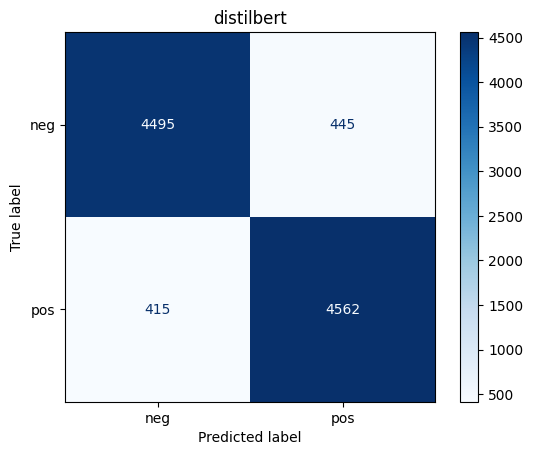

In [16]:
bert.load_state_dict(torch.load('best_distilbert.pt', map_location=device))
bert.eval()
bert_pred = []
with torch.no_grad():
    for enc, _ in bte_dl:
        enc = {k: v.to(device) for k, v in enc.items()}
        bert_pred.append(bert(**enc).logits.argmax(1).cpu().numpy())
bert_pred = np.concatenate(bert_pred)
bert_acc = report('distilbert', yte, bert_pred)

## comparison

| model | test accuracy |
|---|---|
| tf idf + logreg | 0.905 |
| lstm from scratch | 0.862 |
| distilbert fine tuned | 0.913 |

distilbert wins, but only by about a point over the tf idf baseline. the from scratch lstm actually comes in last. on a dataset this clean and balanced the gap between a classical baseline and a transformer is narrow, the transformer earns its lead on the harder reviews. the next cell pulls those out.

In [17]:
# reviews distilbert got right that both simpler models got wrong
mask = (bert_pred == yte) & (lr_pred != yte) & (lstm_pred != yte)
idx = np.where(mask)[0]
print(len(idx), 'reviews bert got right that logreg and lstm both missed\n')
for i in te_r['review'].iloc[idx].str.len().sort_values(ascending=False).index[:4]:
    print('true', 'pos' if yte[i] else 'neg',
          '| bert', 'pos' if bert_pred[i] else 'neg',
          '| logreg', 'pos' if lr_pred[i] else 'neg',
          '| lstm', 'pos' if lstm_pred[i] else 'neg')
    print(te_r['review'].iloc[i][:500], '...\n')

299 reviews bert got right that logreg and lstm both missed

true pos | bert pos | logreg neg | lstm neg
Beat a path to this important documentary that looks like an attractive feature. Forbidden Lie$(2007) is simply a better (cinematic) version of Norma Khouri's book Forbidden Love, and THAT was a best-seller. An onion-peeling of literary fraud and of a pretty woman, Lie$ is the very best in editorialised reality TV. Cleverly edited and colourful, Broinowski's storytelling is chaptered by moving silhouettes of Norma Khouri meaningfully blowing smoke. I disagree (with Variety) that it's overlong; i ...

true neg | bert neg | logreg pos | lstm pos
Office work, especially in this era of computers, multi-functional copy machines, e-mail, voice mail, snail mail and `temps,' is territory ripe with satirical possibilities, a vein previously tapped in such films as `Clockwatchers' and `Office Space,' and very successfully. This latest addition to the temp/humor pool, however, `Haiku Tunnel,' 

## wrap up

final test accuracy: tf idf plus logreg 0.905, lstm 0.862, distilbert 0.913.

- tf idf plus logreg: strong and nearly free. bigrams capture a lot of sentiment and it trains in seconds on cpu. a hard baseline to beat.
- lstm from scratch: 0.862, below the baseline. with no pretrained embeddings it learns word meaning from 40k reviews alone, and tf idf bigrams are already very strong on imdb. it would need glove embeddings or more data to compete.
- distilbert: best at 0.913. the pretraining is what carries it, one epoch of fine tuning is enough. it handles the sarcastic and mixed reviews the other two miss, the 299 test reviews it got right that both simpler models got wrong.

what would help in production: more than one epoch with a learning rate schedule for distilbert, pretrained embeddings for the lstm, and ensembling tf idf with distilbert since they make different mistakes. a larger transformer would push accuracy higher but distilbert is the better speed and accuracy tradeoff for serving.